<h2>Conjunto de datos de gemelos digitales de encendido y PHM del Boeing 787.</h2>

<h2>Se desea inferir los ciclos de vida restantes(y)</h2>

In [66]:
# Esta celda importa librerías para manejo de datos, álgebra y gráficos.
# Sirve para preparar el entorno antes del entrenamiento del modelo.
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para algunas gráficas 3D
%matplotlib inline


Las columnas excluidas son las siguientes

*4 el 94.9% de los datos son NAN
*7 por que todos los datos estan en nan
*24-28 son datos iguales 
*35-36 son ids

columnas iguales
18-20(excluida)
29-30(excluida)
31-32(excluida)
37-38(excluida)

In [67]:
# Esta celda define la ruta del dataset local.
# Sirve para reemplazar dependencias de Google Colab en VS Code.
dataset = 'ignition_health_EXTREME_FAULTS_v42_B787.csv'
print(f'Archivo a usar: {os.path.abspath(dataset)}')

Archivo a usar: e:\USFX\7mo Semestre\Inteligencia Artificial\Laboratorios\Laboratorio2\ignition_health_EXTREME_FAULTS_v42_B787.csv


In [68]:
df = pd.read_csv(dataset, sep=',', header=None)

# 1. Limpia y convierte TODAS las columnas de texto primero
diccionario1 = {'healthy': 0, 'failure': 1, 'critical': 2, 'caution': 3, 'monitor': 4}
nombre_col = df.columns[22]
df[nombre_col] = df[nombre_col].str.strip().map(diccionario1)


#forma de limpiar y convertir varias columnas de texto a números 
cols_texto = [29, 31, 37]
for col in cols_texto:
    nombre_col = df.columns[col]
    df[nombre_col] = df[nombre_col].str.strip()

for col in cols_texto:
    nombre_col = df.columns[col]
    df[nombre_col], categorias = pd.factorize(df[nombre_col])
    print(f"Columna {col}: {list(categorias)}")




y = df.iloc[:, 17].values

excluir = np.r_[4, 6, 7, 17,20, 24:29,30,32, 35:37, 38]
X_idx = [i for i in range(df.shape[1]) if i not in excluir]
X = df.iloc[:, X_idx].values


m = y.size

print(X)
print(X.dtype)  # debería salir float64, no object
print(np.isnan(X.astype(float)).sum())  # debería salir 0

Columna 29: ['NORMAL_OPERATION', 'REPLACE_IGNITER_URGENT', 'INSPECT_EXCITER_BOX', 'MONITOR_PERFORMANCE']
Columna 31: ['GO', 'NO_GO', 'CONDITIONAL']
Columna 37: ['normal', 'misfire', 'severe_degradation', 'hot_start', 'hung_start', 'igniter_fouling', 'electrode_erosion', 'insulation_breakdown', 'exciter_box_failure']
[[4.22373874e+00 2.12113739e+03 1.89908404e+01 ... 1.00000000e+00
  4.03000000e+02 0.00000000e+00]
 [2.96875736e+00 1.77831064e+03 1.59214644e+01 ... 1.00000000e+00
  4.46000000e+02 0.00000000e+00]
 [3.91760137e+00 2.04282139e+03 1.82896663e+01 ... 1.00000000e+00
  4.35000000e+02 0.00000000e+00]
 ...
 [8.55878790e-01 1.92962641e+03 9.00980596e+00 ... 0.00000000e+00
  0.00000000e+00 8.00000000e+00]
 [8.08698254e-01 1.74548711e+03 8.35559039e+00 ... 0.00000000e+00
  0.00000000e+00 8.00000000e+00]
 [1.19301311e+00 2.35897521e+03 1.10143494e+01 ... 0.00000000e+00
  0.00000000e+00 8.00000000e+00]]
float64
0


In [69]:
#verificar que no haya datos no numéricos en las columnas de X
for i in X_idx:
    col = df.iloc[:, i]
    # intenta ver si hay valores no convertibles a número
    no_numericos = pd.to_numeric(col, errors='coerce').isna() & col.notna()
    if no_numericos.any():
        print(f"Columna {i} tiene valores no numéricos, ejemplo: {col[no_numericos].unique()[:5]}")

In [70]:
#codigo para conteo de valores NaN/None en una columna específica
# for i in [4]:
#     nombre_col = df.columns[i]
#     total_nan = df[nombre_col].astype(str).str.strip().isin(['NaN', 'None']).sum()
#     print(f"Columna {i}: {total_nan} de {len(df)} filas son NaN/None ({100*total_nan/len(df):.1f}%)")

In [71]:
print(y.shape)
print(y)

(27000,)
[453 496 485 ...  26  19  43]


In [72]:
print(X.shape)  # debería salir (n, m)
print(X)

(27000, 24)
[[4.22373874e+00 2.12113739e+03 1.89908404e+01 ... 1.00000000e+00
  4.03000000e+02 0.00000000e+00]
 [2.96875736e+00 1.77831064e+03 1.59214644e+01 ... 1.00000000e+00
  4.46000000e+02 0.00000000e+00]
 [3.91760137e+00 2.04282139e+03 1.82896663e+01 ... 1.00000000e+00
  4.35000000e+02 0.00000000e+00]
 ...
 [8.55878790e-01 1.92962641e+03 9.00980596e+00 ... 0.00000000e+00
  0.00000000e+00 8.00000000e+00]
 [8.08698254e-01 1.74548711e+03 8.35559039e+00 ... 0.00000000e+00
  0.00000000e+00 8.00000000e+00]
 [1.19301311e+00 2.35897521e+03 1.10143494e+01 ... 0.00000000e+00
  0.00000000e+00 8.00000000e+00]]


In [73]:
# Esta celda normaliza cada feature restando media y dividiendo por desviación estándar.
# Sirve para que el descenso por gradiente converja más rápido y de forma estable.
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [74]:
# Esta celda aplica la normalización a X.
# Sirve para obtener X_norm, mu y sigma que luego se usan en entrenamiento e inferencias.
X_norm, mu, sigma = featureNormalize(X)

print('Media calculada:', mu)
print('Desviación estándar:', sigma)
print('Primer registro normalizado:')
print(X_norm[0])

Media calculada: [1.09591298e+00 9.80741830e+02 7.34150524e+00 8.82494013e+01
 5.13333333e-02 1.49625721e+00 1.32323955e+00 2.62852041e+00
 6.51482061e-01 6.43023721e+00 3.68459425e+01 1.65029897e-01
 6.59565730e-04 4.01898629e+01 5.87782200e+01 2.73176484e-01
 8.04339041e-06 1.67400000e+00 2.40007407e+00 1.14825926e+00
 7.91037037e-01 4.62518519e-01 8.86481481e+01 2.31111111e+00]
Desviación estándar: [1.43334592e+00 8.59721102e+02 7.07877692e+00 8.39336121e+01
 2.20676737e-01 7.14824410e-02 4.29706026e-02 1.26316054e+01
 3.13034330e+00 2.78457477e+01 7.24220019e+00 3.24634214e-02
 2.84828457e-03 3.22581443e+01 3.92369615e+01 3.53631784e-01
 1.67614698e-05 1.17411193e+00 1.43207179e+00 7.86259739e-01
 8.20005216e-01 4.98593159e-01 1.63228327e+02 2.05468450e+00]
Primer registro normalizado:
[ 2.18218485  1.32647152  1.64567061  1.64964587 -0.23261778  0.16862942
  0.2193648  -0.20809076 -0.20811841 -0.23092349  0.42937719  0.21138918
 -0.23156595  1.704418   -1.4980319   1.74349531  2.0

In [75]:
# Esta celda añade la columna de unos para el término de sesgo/intersección.
# Sirve para que theta_0 sea aprendido por el modelo.
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
print("X",X)

X [[ 1.          2.18218485  1.32647152 ...  1.0779961   1.92584129
  -1.12480097]
 [ 1.          1.30662414  0.92770645 ...  1.0779961   2.18927596
  -1.12480097]
 [ 1.          1.96860252  1.23537687 ...  1.0779961   2.1218857
  -1.12480097]
 ...
 [ 1.         -0.16746424  1.1037121  ... -0.92764714 -0.54309292
   2.76874084]
 [ 1.         -0.20038061  0.88952717 ... -0.92764714 -0.54309292
   2.76874084]
 [ 1.          0.06774368  1.60311685 ... -0.92764714 -0.54309292
   2.76874084]]


In [76]:
np.random.seed(42)
m_total = X.shape[0]
indices = np.random.permutation(m_total)

corte = int(0.8 * m_total)
idx_train, idx_test = indices[:corte], indices[corte:]

X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

print(f"Entrenamiento: {X_train.shape[0]} filas, Prueba: {X_test.shape[0]} filas")

Entrenamiento: 21600 filas, Prueba: 5400 filas


In [77]:
# Esta celda verifica forma y contenido de la matriz de diseño X.
# Sirve para confirmar que X tiene m filas y n+1 columnas.
print('Shape de X:', X_train.shape)
print('Primer vector X con sesgo:')
print(X_train[0])

Shape de X: (21600, 25)
Primer vector X con sesgo:
[ 1.         -0.76458374 -1.14076743 -1.03711493 -1.05141908 -0.23261778
  0.16589557  0.21225416 -0.20809076 -0.20811841 -0.23092349  0.30201939
  0.20973059 -0.23156595 -1.06350144  1.05058543 -0.77248849 -0.47987381
 -0.57405089  1.1172107  -0.1885627   0.25483126 -0.92764714 -0.54309292
 -0.63810824]


In [78]:
# Esta celda define la función de costo para regresión lineal múltiple.
# Sirve para medir el error cuadrático medio escalado del modelo.
def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = 0
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

In [79]:
# Esta celda define descenso por gradiente para optimizar theta.
# Sirve para minimizar iterativamente el costo del modelo.
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

[np.float64(22169.59941456355), np.float64(21259.546058155887), np.float64(20408.453977861525), np.float64(19612.270917696726), np.float64(18867.22515578566), np.float64(18169.806058853235), np.float64(17516.74598504624), np.float64(16905.0034415806), np.float64(16331.747410196744), np.float64(15794.342759440042), np.float64(15290.336668399197), np.float64(14817.445991762273), np.float64(14373.545500914302), np.float64(13956.65694032706), np.float64(13564.938842704836), np.float64(13196.677050270479), np.float64(12850.27589322502), np.float64(12524.249979809925), np.float64(12217.216555561277), np.float64(11927.88839228638), np.float64(11655.067170030352), np.float64(11397.637317847684), np.float64(11154.56028156431), np.float64(10924.869188922155), np.float64(10707.66388455115), np.float64(10502.106309124834), np.float64(10307.416198833775), np.float64(10122.867082966211), np.float64(9947.782558925466), np.float64(9781.532825447177), np.float64(9623.531456113313), np.float64(9473.2323

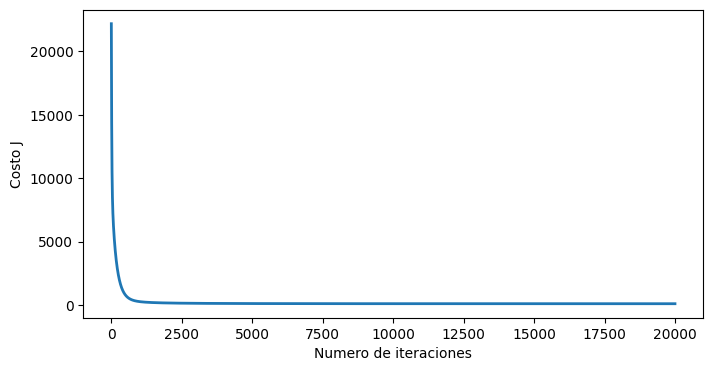

In [80]:
# Esta celda entrena el modelo con descenso por gradiente y grafica convergencia.
# Sirve para obtener theta con el menor costo posible en este enfoque.
alpha = 0.003
num_iters = 20000

theta = np.zeros(X.shape[1]) #esta n+1 por que se añadió la columna de unos a X
theta, J_history = gradientDescentMulti(X_train, y_train, theta, alpha, num_iters)
pyplot.figure(figsize=(8, 4))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
print(J_history)

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))


# Esta celda calcula la segunda predicción usando descenso por gradiente.
# Sirve para comparar predicción vs valor real en otro ejemplo.

idx2 = 5300
X_array =  X_test[idx2]

price = np.dot(X_array, theta)
print(f'Predicción para ejemplo {idx2}: real={y_test[idx2]:.2f}, predicho={price:.2f}')



In [81]:
# Esta celda prepara un segundo ejemplo para inferencia con GD.
# Sirve para reutilizar el modelo entrenado en otro registro del dataset.

idx2 = 10
X_array = X_test[idx2]

idx3 = 300
X_array2 = X_test[idx3]

In [82]:
# Esta celda calcula la segunda predicción usando descenso por gradiente.
# Sirve para comparar predicción vs valor real en otro ejemplo.
price = np.dot(X_array, theta)
print(f'Predicción para ejemplo {idx2}: real={y_test[idx2]:.2f}, predicho={price:.2f}')

price2 = np.dot(X_array2, theta)
print(f'Predicción para ejemplo {idx3}: real={y_test[idx3]:.2f}, predicho={price2:.2f}')


#presicion del modelo con descenso por gradiente
predicciones_gd = np.dot(X_test, theta)

print('-----------------------Resultados de la ecuación normal-----------------------')

# Error porcentual (MAPE), evitando división por cero
mask = y_test != 0
error_pct_ne = np.mean(np.abs((y_test[mask] - predicciones_gd[mask]) / y_test[mask])) * 100
print(f'Error porcentual medio (MAPE) con ecuación normal: {error_pct_ne:.2f}%')


# R² como porcentaje de precisión
r2_ne = 1 - (np.sum((y_test - predicciones_gd) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))
print(f'Precisión del modelo (R²) con ecuación normal: {100 - error_pct_ne:.2f}%')

Predicción para ejemplo 10: real=27.00, predicho=28.71
Predicción para ejemplo 300: real=124.00, predicho=97.64
-----------------------Resultados de la ecuación normal-----------------------
Error porcentual medio (MAPE) con ecuación normal: 33.21%
Precisión del modelo (R²) con ecuación normal: 66.79%


<h1>Ecuacion de la normal</h1>

In [83]:
df = pd.read_csv(dataset, sep=',', header=None)

# 1. Limpia y convierte TODAS las columnas de texto primero
diccionario1 = {'healthy': 0, 'failure': 1, 'critical': 2, 'caution': 3, 'monitor': 4}
nombre_col = df.columns[22]
df[nombre_col] = df[nombre_col].str.strip().map(diccionario1)


#forma de limpiar y convertir varias columnas de texto a números 
cols_texto = [29, 31, 37]
for col in cols_texto:
    nombre_col = df.columns[col]
    df[nombre_col] = df[nombre_col].str.strip()

for col in cols_texto:
    nombre_col = df.columns[col]
    df[nombre_col], categorias = pd.factorize(df[nombre_col])
    print(f"Columna {col}: {list(categorias)}")




y = df.iloc[:, 17].values

excluir = np.r_[4, 6, 7, 17, 20, 24:29,30,32, 35:37, 38]
X_idx = [i for i in range(df.shape[1]) if i not in excluir]
X = df.iloc[:, X_idx].values


m = y.size

print(X)
print(X.dtype)  # debería salir float64, no object
print(np.isnan(X.astype(float)).sum())  # debería salir 0

Columna 29: ['NORMAL_OPERATION', 'REPLACE_IGNITER_URGENT', 'INSPECT_EXCITER_BOX', 'MONITOR_PERFORMANCE']
Columna 31: ['GO', 'NO_GO', 'CONDITIONAL']
Columna 37: ['normal', 'misfire', 'severe_degradation', 'hot_start', 'hung_start', 'igniter_fouling', 'electrode_erosion', 'insulation_breakdown', 'exciter_box_failure']
[[4.22373874e+00 2.12113739e+03 1.89908404e+01 ... 1.00000000e+00
  4.03000000e+02 0.00000000e+00]
 [2.96875736e+00 1.77831064e+03 1.59214644e+01 ... 1.00000000e+00
  4.46000000e+02 0.00000000e+00]
 [3.91760137e+00 2.04282139e+03 1.82896663e+01 ... 1.00000000e+00
  4.35000000e+02 0.00000000e+00]
 ...
 [8.55878790e-01 1.92962641e+03 9.00980596e+00 ... 0.00000000e+00
  0.00000000e+00 8.00000000e+00]
 [8.08698254e-01 1.74548711e+03 8.35559039e+00 ... 0.00000000e+00
  0.00000000e+00 8.00000000e+00]
 [1.19301311e+00 2.35897521e+03 1.10143494e+01 ... 0.00000000e+00
  0.00000000e+00 8.00000000e+00]]
float64
0


In [84]:
# Esta celda define la ecuación normal para estimar theta sin iteraciones.
# Sirve como método alternativo al descenso por gradiente.
def normalEqn(X, y):
    theta = np.zeros(X.shape[1])
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)
    return theta

In [85]:
theta = normalEqn(X_train, y_train)
print('Primeros 5 valores de theta (ecuación normal):', theta[:5])

# Predicción de un solo ejemplo, solo para inspección puntual
idx3 = 300
X_array_ne = X_test[idx3]
price_ne = np.dot(X_array_ne, theta)
print(f'Predicción (ecuación normal) ejemplo {idx3}: real={y_test[idx3]:.2f}, predicho={price_ne:.2f}')

# Predicciones para TODO el conjunto de prueba (esto es lo que faltaba)
predicciones_ne = np.dot(X_test, theta)


print('-----------------------Resultados de la ecuación normal-----------------------')

# Error porcentual (MAPE), evitando división por cero
mask = y_test != 0
error_pct_ne = np.mean(np.abs((y_test[mask] - predicciones_ne[mask]) / y_test[mask])) * 100
print(f'Error porcentual medio (MAPE) con ecuación normal: {error_pct_ne:.2f}%')


# R² como porcentaje de precisión
r2_ne = 1 - (np.sum((y_test - predicciones_ne) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))
print(f'Precisión del modelo (R²) con ecuación normal: {100 - error_pct_ne:.2f}%')


Primeros 5 valores de theta (ecuación normal): [128.23069776  -8.16319675   0.6087862   -2.24642517  17.94404343]
Predicción (ecuación normal) ejemplo 300: real=124.00, predicho=98.23
-----------------------Resultados de la ecuación normal-----------------------
Error porcentual medio (MAPE) con ecuación normal: 31.92%
Precisión del modelo (R²) con ecuación normal: 68.08%
